In [57]:
# %env CUDA_VISIBLE_DEVICES=1
import os
os.chdir("/Users/Owner/OneDrive/Desktop/")

In [58]:
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from random import shuffle

import pandas as pd

import pickle

from sklearn.svm import SVC,LinearSVC
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier,ExtraTreesClassifier
from sklearn import svm,metrics,preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn import preprocessing
from dataset import CustomEmotionDataset

#from scipy.misc import imread, imresize

%matplotlib inline

# PyTorch

In [59]:
import glob
from itertools import chain
import os
import random
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from tqdm.notebook import tqdm


print(f"Torch: {torch.__version__}")

Torch: 2.2.2+cu118


In [73]:
# Training settings
batch_size = 48 #64# 32# 32 #16 #8 #
epochs = 40
lr = 3e-5
gamma = 0.7
seed = 42
device = 'cuda'
use_cuda = torch.cuda.is_available()
print(use_cuda)

True


In [74]:
USE_ENET2=True #False #

In [75]:
IMG_SIZE=260 if USE_ENET2 else 224 # 300 # 80 #
train_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    ]
)

test_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE,IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    ]
)
print(test_transforms)

Compose(
    Resize(size=(260, 260), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [76]:
#adapted from https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html
def set_parameter_requires_grad(model, requires_grad):
    for param in model.parameters():
        param.requires_grad = requires_grad

# FER only model 

In [77]:
kwargs = {'num_workers': 16, 'pin_memory': True, 'persistent_workers':True, 'prefetch_factor':2} if use_cuda else {}

# kwargs = {'num_workers': 4, 'pin_memory': True} if use_cuda else {}

train_dataset = CustomEmotionDataset(
    csv_file='./processed_affectnet_va/metadata.csv',
    root='./AffectNetVA/',
    transform=train_transforms,
    split="Train"
)

val_dataset = CustomEmotionDataset(
    csv_file='./processed_affectnet_va/metadata.csv',
    root='./AffectNetVA/',
    transform=test_transforms,
    split="Validation"
)

test_dataset = CustomEmotionDataset(
    csv_file='./processed_affectnet_va/metadata.csv',
    root='./AffectNetVA/',
    transform=test_transforms,
    split="Test"
)



train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, **kwargs)

print(len(train_dataset), len(test_dataset))

58803 5000


In [78]:
(unique, counts) = np.unique(train_dataset.targets, return_counts=True)
cw=1/counts
cw/=cw.min()
class_weights = {i:cwi for i,cwi in zip(unique,cw)}
print(counts, class_weights.values())



[10000 10000 10000 10000  5000  3803 10000] dict_values([1.0, 1.0, 1.0, 1.0, 2.0, 2.6295030239284776, 1.0])


In [79]:
num_classes = len(np.unique(train_dataset.targets))
print(f"Number of classes: {num_classes}")

Number of classes: 7


In [80]:
# loss function
weights = torch.FloatTensor(list(class_weights.values())).cuda()
if False:
    criterion = nn.CrossEntropyLoss(weight=weights)
    #criterion = nn.CrossEntropyLoss()
else:
    def label_smooth(target, n_classes: int, label_smoothing=0.1):
        # convert to one-hot
        batch_size = target.size(0)
        target = torch.unsqueeze(target, 1)
        soft_target = torch.zeros((batch_size, n_classes), device=target.device)
        soft_target.scatter_(1, target, 1)
        # label smoothing
        soft_target = soft_target * (1 - label_smoothing) + label_smoothing / n_classes
        return soft_target

    def cross_entropy_loss_with_soft_target(pred, soft_target):
        #logsoftmax = nn.LogSoftmax(dim=-1)
        return torch.mean(torch.sum(- weights*soft_target * torch.nn.functional.log_softmax(pred, -1), 1))

    def cross_entropy_with_label_smoothing(pred, target):
        soft_target = label_smooth(target, pred.size(1)) #num_classes) #
        return cross_entropy_loss_with_soft_target(pred, soft_target)

    criterion=cross_entropy_with_label_smoothing

In [81]:
from robust_optimization import RobustOptimizer
import copy
def train(model,n_epochs=epochs, learningrate=lr, robust=False):
    # optimizer
    if robust:
        optimizer = RobustOptimizer(filter(lambda p: p.requires_grad, model.parameters()), optim.Adam, lr=learningrate)
        #print(optimizer)
    else:
        optimizer=optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learningrate)
    # scheduler
    #scheduler = StepLR(optimizer, step_size=1, gamma=gamma)
    best_acc=0
    best_model=None
    for epoch in range(n_epochs):
        epoch_loss = 0
        epoch_accuracy = 0
        model.train()
        for data, label in tqdm(train_loader):
            data = data.to(device)
            label = label.to(device)
            # label = {key: value.to(device) for key, value in label.items()}

            output = model(data)
            # loss = criterion(output, label["emotion"])
            loss = criterion(output, label)

            if robust:
                #optimizer.zero_grad()
                loss.backward()
                optimizer.first_step(zero_grad=True)
  
                # second forward-backward pass
                output = model(data)
                loss = criterion(output, label)
                # loss = criterion(output, label["emotion"])
                loss.backward()
                optimizer.second_step(zero_grad=True)
            else:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            acc = (output.argmax(dim=1) == label).float().sum()
            epoch_accuracy += acc
            epoch_loss += loss
        epoch_accuracy /= len(train_dataset)
        epoch_loss /= len(train_dataset)
        
        model.eval()
        with torch.no_grad():
            epoch_val_accuracy = 0
            epoch_val_loss = 0
            for data, label in test_loader:
                data = data.to(device)
                label = label.to(device)

                val_output = model(data)
                val_loss = criterion(val_output, label)

                acc = (val_output.argmax(dim=1) == label).float().sum()
                epoch_val_accuracy += acc
                epoch_val_loss += val_loss
        epoch_val_accuracy /= len(test_dataset)
        epoch_val_loss /= len(test_dataset)
        print(
            f"Epoch : {epoch+1} - loss : {epoch_loss:.4f} - acc: {epoch_accuracy:.4f} - val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
        )
        if best_acc<epoch_val_accuracy:
            best_acc=epoch_val_accuracy
            best_model=copy.deepcopy(model.state_dict())
        #scheduler.step()
    
    if best_model is not None:
        model.load_state_dict(best_model)
        print(f"Best acc:{best_acc}")
        model.eval()
        with torch.no_grad():
            epoch_val_accuracy = 0
            epoch_val_loss = 0
            for data, label in test_loader:
                data = data.to(device)
                label = label.to(device)

                val_output = model(data)
                val_loss = criterion(val_output, label)

                acc = (val_output.argmax(dim=1) == label).float().sum()
                epoch_val_accuracy += acc
                epoch_val_loss += val_loss
        epoch_val_accuracy /= len(test_dataset)
        epoch_val_loss /= len(test_dataset)
        print(
            f"val_loss : {epoch_val_loss:.4f} - val_acc: {epoch_val_accuracy:.4f}\n"
        )
    else:
        print(f"No best model Best acc:{best_acc}")

### Finetune CNN 

In [82]:
from torchvision.models import resnet101,mobilenet_v2
import timm

In [83]:
model=timm.create_model('tf_efficientnet_b0_ns', pretrained=False)
model.classifier=torch.nn.Identity()
model.load_state_dict(torch.load('./state_vggface2_enet0_new.pt')) #_new

C:\Users\Owner\.conda\envs\Pytorch\Lib\site-packages\timm\models\_factory.py:114: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


<All keys matched successfully>

In [84]:
model.classifier=nn.Sequential(nn.Linear(in_features=1280, out_features=num_classes)) #1792 #1280 #1536
#model.head.fc=nn.Linear(in_features=3072, out_features=num_classes)
#model.head=nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))
model=model.to(device)
print(model)

EfficientNet(
  (conv_stem): Conv2dSame(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          16, eps=

In [85]:
set_parameter_requires_grad(model, requires_grad=False)
set_parameter_requires_grad(model.classifier, requires_grad=True)
train(model,3,0.001,robust=True)
#Best acc:0.48875007033348083
#7: Best acc:0.558712363243103

  0%|          | 0/1226 [00:00<?, ?it/s]

Epoch : 1 - loss : 0.0383 - acc: 0.4723 - val_loss : 0.0266 - val_acc: 0.3892



  0%|          | 0/1226 [00:00<?, ?it/s]

Epoch : 2 - loss : 0.0360 - acc: 0.5289 - val_loss : 0.0262 - val_acc: 0.3964



  0%|          | 0/1226 [00:00<?, ?it/s]

Epoch : 3 - loss : 0.0355 - acc: 0.5382 - val_loss : 0.0277 - val_acc: 0.3928

Best acc:0.39640000462532043
val_loss : 0.0262 - val_acc: 0.3964



In [86]:
set_parameter_requires_grad(model, requires_grad=True)
train(model,6,1e-4,robust=True)

  0%|          | 0/1226 [00:00<?, ?it/s]

Epoch : 1 - loss : 0.0335 - acc: 0.5795 - val_loss : 0.0240 - val_acc: 0.4334



  0%|          | 0/1226 [00:00<?, ?it/s]

Epoch : 2 - loss : 0.0310 - acc: 0.6310 - val_loss : 0.0233 - val_acc: 0.4450



  0%|          | 0/1226 [00:00<?, ?it/s]

...

Epoch : 4 - loss : 0.0280 - acc: 0.6912 - val_loss : 0.0236 - val_acc: 0.4462



  0%|          | 0/1226 [00:00<?, ?it/s]

Epoch : 5 - loss : 0.0265 - acc: 0.7195 - val_loss : 0.0237 - val_acc: 0.4512



  0%|          | 0/1226 [00:00<?, ?it/s]

Epoch : 6 - loss : 0.0250 - acc: 0.7523 - val_loss : 0.0241 - val_acc: 0.4404

Best acc:0.4511999785900116
val_loss : 0.0237 - val_acc: 0.4512



In [87]:
PATH='/Users/Owner/OneDrive/Desktop/Mine_single_enet_b2_7.pt'
model_name='Mine_single_enet2_7_pt'

In [88]:
# Save
torch.save(model, PATH)

In [89]:
# Load
PATH = "/Users/Owner/OneDrive/Desktop/Mine_single_enet_b2_7.pt"
print(PATH)
model = torch.load(PATH)
model=model.eval()

/Users/Owner/OneDrive/Desktop/Mine_single_enet_b2_7.pt


In [1]:
idx_to_class = {0:'Neutral',1:'Happiness', 2:'Sadness', 3:'Surprise', 4:'Fear', 5:'Disgust', 6:'Anger'}
class_to_idx={cls:idx for idx,cls in affectnet_expr2emotion.items()}

In [2]:
class_to_idx=train_dataset.class_to_idx
print(class_to_idx)
idx_to_class={idx:cls for cls,idx in class_to_idx.items()}
print(idx_to_class)

NameError: name 'train_dataset' is not defined

In [100]:
model = model.to(device)
model.eval()

with torch.no_grad():
    epoch_val_accuracy = 0
    for data, label in test_loader:
        data = data.to(device)
        label = label.to(device)  # Assuming labels are single tensors now

        # Forward pass
        val_output = model(data)

        # Compute accuracy for emotion classification
        acc = (val_output[:, :num_classes].argmax(dim=1) == label).float().sum()
        epoch_val_accuracy += acc

# Normalize accuracy by the number of samples
epoch_val_accuracy /= len(test_dataset)

# Print the results
print(f"Validation Accuracy: {epoch_val_accuracy:.4f}")



Validation Accuracy: 0.4512


In [101]:
import os
from PIL import Image
from tqdm import tqdm
import numpy as np
import pandas as pd
import torch

# Paths and configuration
metadata_path = "./processed_affectnet_va/metadata.csv"  # Path to your metadata
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load metadata
metadata = pd.read_csv(metadata_path)

# Filter metadata for validation split
val_metadata = metadata[metadata["split"].str.strip() == "Validation"]

# Containers for predictions and labels
y_val, y_scores_val = [], [], 

# Ensure the model is in evaluation mode
model.eval()

# Iterate through validation metadata
print(f"Processing {len(val_metadata)} validation samples...", flush=True)
for i, row in tqdm(val_metadata.iterrows(), total=len(val_metadata), desc="Processing Validation Data"):
    try:
        # Extract image path and labels
        img_path = row["image_path"]  # Path to the image
        emotion_label = int(row["emotion"])  # Emotion class label
        # valence_gt = row["valence"]  # Ground truth valence
        # arousal_gt = row["arousal"]  # Ground truth arousal

        # Load and transform the image
        img = Image.open(img_path).convert("RGB")  # Ensure RGB format
        img_tensor = test_transforms(img).unsqueeze(0).to(device)  # Add batch dimension and move to GPU

        # Get model predictions
        scores = model(img_tensor)
        scores = scores[0].data.cpu().numpy()  # Move to CPU and convert to numpy

        # Separate outputs
        num_classes = len(class_to_idx)  # Number of emotion classes
        class_scores = scores[:num_classes]  # Class probabilities
        # valence_pred = scores[num_classes]  # Predicted valence
        # arousal_pred = scores[num_classes + 1]  # Predicted arousal

        # Append predictions and labels
        y_scores_val.append(class_scores)
        y_val.append(emotion_label)
        # y_valence.append((valence_pred, valence_gt))  # (predicted, ground truth)
        # y_arousal.append((arousal_pred, arousal_gt))  # (predicted, ground truth)

    except Exception as e:
        print(f"Error processing sample {i} (image: {img_path}): {e}", flush=True)

# Convert lists to numpy arrays for further evaluation
y_scores_val = np.array(y_scores_val)
y_val = np.array(y_val)
# y_valence = np.array(y_valence)
# y_arousal = np.array(y_arousal)

# Print summary of processed data
print(f"Validation Scores Shape: {y_scores_val.shape}")
print(f"Validation Labels Shape: {y_val.shape}")
# print(f"Validation Valence Shape: {y_valence.shape}")
# print(f"Validation Arousal Shape: {y_arousal.shape}")

Processing 3500 validation samples...


Processing Validation Data: 100%|██████████████████████████████████████████████████| 3500/3500 [00:43<00:00, 80.61it/s]

Validation Scores Shape: (3500, 7)
Validation Labels Shape: (3500,)


In [104]:
y_pred=np.argmax(y_scores_val,axis=1)
acc=100.0*(y_val==y_pred).sum()/len(y_val)
print(acc)

y_train=np.array(train_dataset.targets)

for i in range(y_scores_val.shape[1]):
    _val_acc=(y_pred[y_val==i]==i).sum()/(y_val==i).sum()
    print('%s %d/%d acc: %f' %(idx_to_class[i],(y_train==i).sum(),(y_val==i).sum(),100*_val_acc))

64.45714285714286
Neutral 10000/500 acc: 57.600000
Happiness 10000/500 acc: 84.600000
Sadness 10000/500 acc: 64.600000
Surprise 10000/500 acc: 54.200000
Fear 5000/500 acc: 62.800000
Disgust 3803/500 acc: 65.000000
Anger 10000/500 acc: 62.400000


['Neutral', 'Happiness', 'Sadness', 'Surprise', 'Fear', 'Disgust', 'Anger']
(3500,) (3500,) 0.6445714285714286


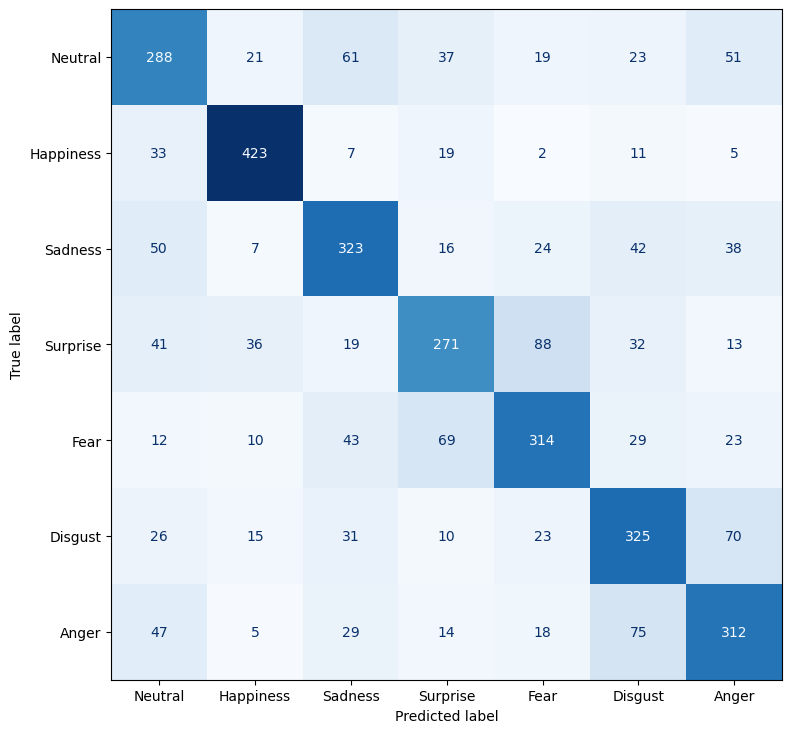

In [105]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Assuming y_true, y_pred, and labels are already defined
labels = list(class_to_idx.keys())
print(labels)

def plt_conf_matrix(y_true, y_pred, labels):
    print(y_pred.shape, y_true.shape, (y_pred == y_true).mean())

    # Compute the confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))

    # Create a ConfusionMatrixDisplay instance and plot it
    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=False)  # Adjust cmap and colorbar as needed
    plt.tight_layout()
    plt.show()

# Call the function with your data
plt_conf_matrix(y_val, y_pred, labels)
